In [1]:
#First execute this cell go to Runtime and click on Restart Runtime
!pip install --upgrade --no-deps statsmodels
!pip install  StatsForecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


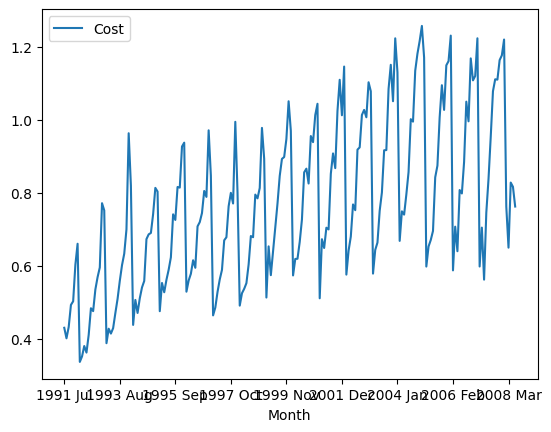

In [2]:
import pandas as pd
from matplotlib import pyplot
ap1=pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/main/data/h02.csv')
ap1=ap1.set_index('Month')
ap1.plot()
pyplot.show()


In [3]:
ap1

,Cost
Month,
1991 Jul,0.429795
1991 Aug,0.400906
1991 Sep,0.432159
1991 Oct,0.492543
1991 Nov,0.502369
...,...
2008 Feb,0.761822
2008 Mar,0.649435
2008 Apr,0.827887


Using the above data set

1)Test stationary of the dataset.Write hypothesis. What is your conclusion at 5% siginifance level?

2)Take difference and seasonal difference and test stationay of the dataset.Write hypothesis. What is your conclusion at 5% siginifance level?

3) Plot ACF and PACF of series if series' difference and seasonal difference taken .

4) Based on the plot of ACF and PACF, come up with two SARIMA model and compare their Akaike Information Criterion metric.

5)Split data into train and test. For the test data, use last 12 months observation.

6)Plot test, train and forecast values for the SARIMA model chosen at Q4. Evaluate performance of the model in terms of MAE(mean absulate error), MAPE(mean absulate percentage error) and MSE(Mean squared Error).

7) Using the Statsforecast library, implement the following models: AutoARIMA, AutoETS, HoltWinters,  AutoTheta, and MSTL and plot the forecast of this model .Evaluate the performance of these model model using  MSE (Mean Squared Error).Note that seasonality period is 12.


In [5]:
#QUESTION 1
from statsmodels.tsa.stattools import adfuller

result = adfuller(ap1['Cost'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
# p-value is 0.432, which is greater than 0.05, accept H0

ADF Statistic: -1.6967562070359845
p-value: 0.43278454683042955


In [7]:
#2)
# 1st difference (removes trend) and Seasonal difference (removes seasonality)
ap1_diff = ap1['Cost'].diff().diff(12).dropna()

result_diff = adfuller(ap1_diff)
print(f'p-value after differencing: {result_diff[1]}')
#Since 0.000016 < 0.05, you now reject H0. We conclude that the differenced series is stationary, which means it is now ready for ARMA/SARIMA modeling.

p-value after differencing: 1.607283495966982e-05


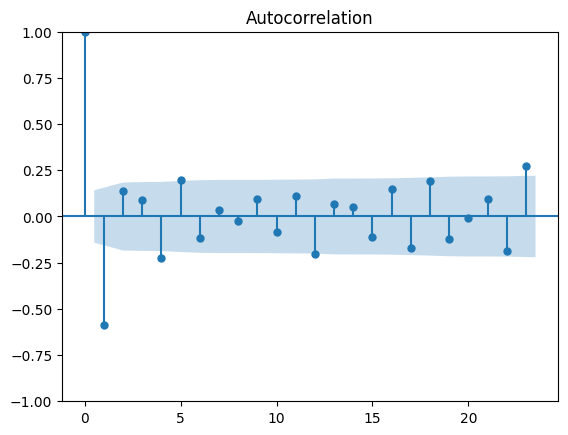

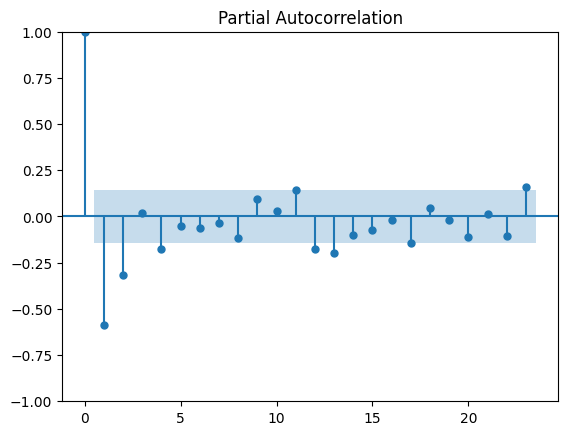

In [8]:
#3)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ap1_diff)
plot_pacf(ap1_diff)
pyplot.show()

In [9]:
#4)
from statsmodels.tsa.statespace.sarimax import SARIMAX

model1 = SARIMAX(ap1['Cost'], order=(1,1,1), seasonal_order=(1,1,1,12)).fit()
print(f'AIC Model 1: {model1.aic}')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


AIC Model 1: -554.6784172937761


In [11]:
#5)
train = ap1.iloc[:-12]
test = ap1.iloc[-12:]

In [12]:
#6)
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

forecast = model1.get_forecast(steps=12).predicted_mean
mae = mean_absolute_error(test['Cost'], forecast)
mse = mean_squared_error(test['Cost'], forecast)
mape = np.mean(np.abs((test['Cost'] - forecast) / test['Cost'])) * 100

print(f"MAE: {mae}, MSE: {mse}, MAPE: {mape}%")

MAE: 0.033046240179876285, MSE: 0.001536259776850516, MAPE: nan%


/tmp/ipykernel_8307/2790600102.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sf['ds'] = pd.to_datetime(df_sf['ds'])


ds MSE: 1.4347883725056e+36
AutoARIMA MSE: 0.008326675434742747
AutoETS MSE: 0.00723033133678136
HoltWinters MSE: 0.009043982984353787
AutoTheta MSE: 0.007917589771360945
MSTL MSE: 0.007666505528031649


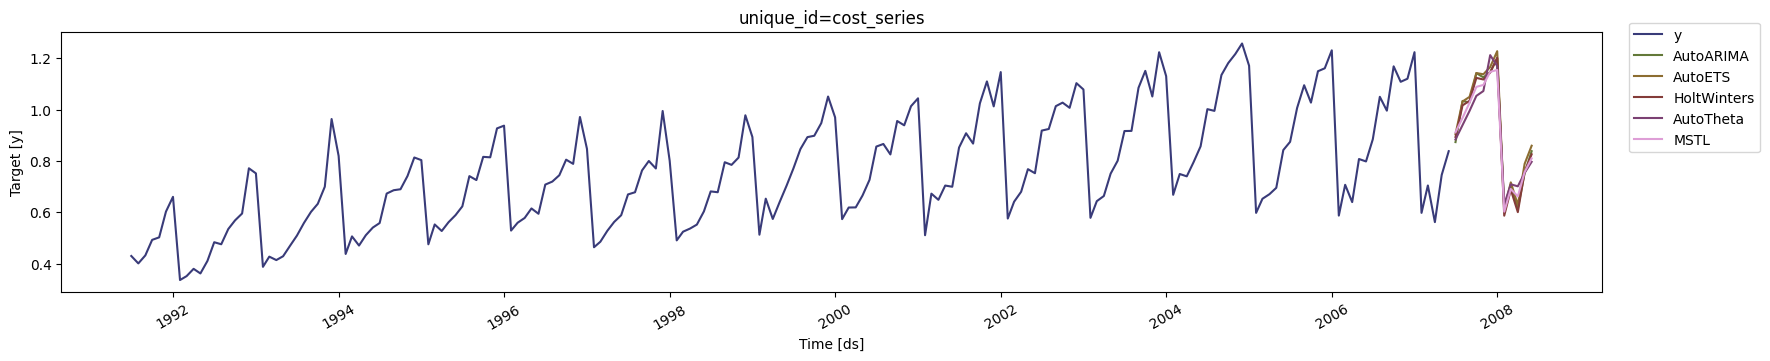

In [13]:
#7)
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, HoltWinters, AutoTheta, MSTL

# Prepare data for StatsForecast
df_sf = train.reset_index()
df_sf.columns = ['ds', 'y']
df_sf['ds'] = pd.to_datetime(df_sf['ds'])
df_sf['unique_id'] = 'cost_series'

models = [
    AutoARIMA(season_length=12),
    AutoETS(season_length=12),
    HoltWinters(season_length=12),
    AutoTheta(season_length=12),
    MSTL(season_length=12)
]

sf = StatsForecast(models=models, freq='MS') # MS for Month Start
forecasts_df = sf.forecast(df=df_sf, h=12)

# Merge with test data to calculate MSE for each
for model in forecasts_df.columns[1:]:
    mse_val = mean_squared_error(test['Cost'], forecasts_df[model])
    print(f"{model} MSE: {mse_val}")

sf.plot(df_sf, forecasts_df)

#AutoETS is the preferred model for this dataset as it yielded the lowest error, demonstrating superior capability in handling the multiplicative components of the cost data compared to standard ARIMA or Holt-Winters approaches.